In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

In [3]:
data = pd.read_csv("../Data/삼성전자-주가.csv")
data.head()

,일자,시가,고가,저가,종가,거래량
0,20200107,55700,56400,55600,55800,9893846
1,20200106,54900,55600,54600,55500,10278951
2,20200103,56000,56600,54900,55500,15422255
3,20200102,55500,56000,55000,55200,12993228
4,20191230,56200,56600,55700,55800,8356767


In [4]:
data.shape

(9288, 6)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9288 entries, 0 to 9287
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   일자      9288 non-null   int64
 1   시가      9288 non-null   int64
 2   고가      9288 non-null   int64
 3   저가      9288 non-null   int64
 4   종가      9288 non-null   int64
 5   거래량     9288 non-null   int64
dtypes: int64(6)
memory usage: 435.5 KB


In [6]:
data.describe()

,일자,시가,고가,저가,종가,거래량
count,9.288000e+03,9288.000000,9288.000000,9288.000000,9288.000000,9.288000e+03
mean,2.001347e+07,11108.556417,11228.754522,10986.106481,11108.235465,1.645823e+07
std,1.015376e+05,13792.646300,13920.105135,13658.809496,13790.922497,1.701535e+07
min,1.985010e+07,116.000000,116.000000,115.000000,116.000000,0.000000e+00
25%,1.992121e+07,624.000000,632.000000,620.000000,623.000000,3.833986e+06
50%,2.001032e+07,5045.000000,5190.000000,4955.000000,5075.000000,1.199608e+07
75%,2.010080e+07,15920.000000,16050.000000,15740.000000,15920.000000,2.284080e+07
max,2.020011e+07,57500.000000,57520.000000,56760.000000,57220.000000,3.266220e+08


---
### 전처리(PreProcessing)

In [8]:
# 시계열 - 날짜 시간
# 범주형 - 단어
# 연속형 - 숫자


# 일자 컬럼을 날짜형으로 변환

pd.to_datetime(data.일자, format="%Y%m%d")

0      2020-01-07
1      2020-01-06
2      2020-01-03
3      2020-01-02
4      2019-12-30
          ...    
9283   1985-01-09
9284   1985-01-08
9285   1985-01-07
9286   1985-01-05
9287   1985-01-04
Name: 일자, Length: 9288, dtype: datetime64[ns]

In [9]:
# 적용
data['일자'] = pd.to_datetime(data.일자, format="%Y%m%d")
data.head()

,일자,시가,고가,저가,종가,거래량
0,2020-01-07,55700,56400,55600,55800,9893846
1,2020-01-06,54900,55600,54600,55500,10278951
2,2020-01-03,56000,56600,54900,55500,15422255
3,2020-01-02,55500,56000,55000,55200,12993228
4,2019-12-30,56200,56600,55700,55800,8356767


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9288 entries, 0 to 9287
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   일자      9288 non-null   datetime64[ns]
 1   시가      9288 non-null   int64         
 2   고가      9288 non-null   int64         
 3   저가      9288 non-null   int64         
 4   종가      9288 non-null   int64         
 5   거래량     9288 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 435.5 KB


In [11]:
# 연도, 월, 일 컬럼 추가
data['연도'] = data.일자.dt.year
data['월'] = data.일자.dt.month
data['일'] = data.일자.dt.day

data.head()

,일자,시가,고가,저가,종가,거래량,연도,월,일
0,2020-01-07,55700,56400,55600,55800,9893846,2020,1,7
1,2020-01-06,54900,55600,54600,55500,10278951,2020,1,6
2,2020-01-03,56000,56600,54900,55500,15422255,2020,1,3
3,2020-01-02,55500,56000,55000,55200,12993228,2020,1,2
4,2019-12-30,56200,56600,55700,55800,8356767,2019,12,30


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9288 entries, 0 to 9287
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   일자      9288 non-null   datetime64[ns]
 1   시가      9288 non-null   int64         
 2   고가      9288 non-null   int64         
 3   저가      9288 non-null   int64         
 4   종가      9288 non-null   int64         
 5   거래량     9288 non-null   int64         
 6   연도      9288 non-null   int32         
 7   월       9288 non-null   int32         
 8   일       9288 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(5)
memory usage: 544.3 KB


---
### 시각화

In [19]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

In [20]:
# 데이터의 범위 확인하기
np.sort(data.연도.unique())

array([1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020], dtype=int32)

In [21]:
# 1990년 이후의 Data만 사용
# df = \
# data.drop(
#   ['1985','1986','1987','1988','1989'],
#   axis='row',
#   inplace=True
# )
# df.head()

df = data[data.연도 >= 1990]
df.연도.unique()

array([2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010,
       2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999,
       1998, 1997, 1996, 1995, 1994, 1993, 1992, 1991, 1990], dtype=int32)

In [22]:
import seaborn as sns

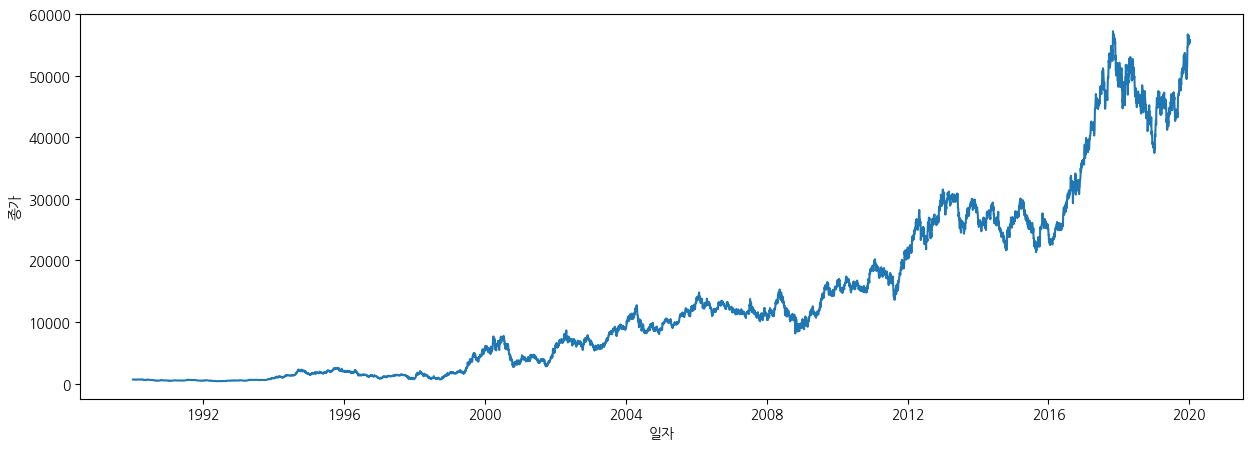

In [23]:
plt.figure(figsize=(15,5))
sns.lineplot(
  x=df.일자,
  y=df.종가
)

plt.show()

In [25]:
# 현재 내림차순 정렬로 되어 있는 df 를 오름차순으로 정렬

df = df.sort_values(
  by='일자',
  ascending=True
).reset_index(drop=True)

df.head()

,일자,시가,고가,저가,종가,거래량,연도,월,일
0,1990-01-03,673,689,661,685,1715032,1990,1,3
1,1990-01-04,689,701,685,693,2738562,1990,1,4
2,1990-01-05,689,693,678,678,1790849,1990,1,5
3,1990-01-06,685,689,681,681,1724183,1990,1,6
4,1990-01-08,681,687,673,673,966666,1990,1,8


In [30]:
# 일자와 관련된 컬럼 제외하고 data의 크기 비교
columns = ['시가', '고가', '저가', '종가', '거래량']
df[['시가', '고가', '저가', '종가', '거래량']].describe()

,시가,고가,저가,종가,거래량
count,7828.000000,7828.000000,7828.000000,7828.000000,7.828000e+03
mean,13102.048927,13243.941620,12957.559658,13101.641415,1.908968e+07
std,14157.419071,14285.315014,14022.456207,14155.504533,1.722374e+07
min,390.000000,396.000000,387.000000,393.000000,0.000000e+00
25%,1410.000000,1434.000000,1390.000000,1410.000000,8.008238e+06
50%,8865.000000,8960.000000,8745.000000,8860.000000,1.453765e+07
75%,21430.000000,21680.000000,21200.000000,21480.000000,2.546348e+07
max,57500.000000,57520.000000,56760.000000,57220.000000,3.266220e+08


In [28]:
df[['시가', '고가', '저가', '종가', '거래량']].corr()

,시가,고가,저가,종가,거래량
시가,1.000000,0.999921,0.999924,0.999822,-0.124916
고가,0.999921,1.000000,0.999922,0.999922,-0.122721
저가,0.999924,0.999922,1.000000,0.999929,-0.126815
종가,0.999822,0.999922,0.999929,1.000000,-0.124825
거래량,-0.124916,-0.122721,-0.126815,-0.124825,1.000000


> 거래량과 다른 컬럼과 차이가 있으므로 정규화

In [29]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss = StandardScaler()
dfss = ss.fit_transform(df[columns])
df_ss = pd.DataFrame(dfss)

df_ss

# 표준화는 각 컬럼별 성격이 비슷할 때 하는것이다.

,0,1,2,3,4
0,-0.877974,-0.878927,-0.876975,-0.877216,-1.008826
1,-0.876844,-0.878087,-0.875263,-0.876651,-0.949397
2,-0.876844,-0.878647,-0.875763,-0.877711,-1.004424
3,-0.877126,-0.878927,-0.875549,-0.877499,-1.008295
4,-0.877409,-0.879067,-0.876119,-0.878064,-1.052278
...,...,...,...,...,...
7823,3.044390,3.035203,3.048337,3.016571,-0.623186
7824,2.994943,2.993199,2.998414,2.974182,-0.353979
7825,3.030262,3.035203,2.991282,2.995377,-0.212942
7826,2.952559,2.965196,2.969886,2.995377,-0.511578


---
### 정규화

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [35]:
scaler = MinMaxScaler()
df_Scaled = scaler.fit_transform(df[columns])
dfScaled = pd.DataFrame(df_Scaled)
dfScaled.columns = columns

dfScaled

,시가,고가,저가,종가,거래량
0,0.004955,0.005129,0.004860,0.005138,0.005251
1,0.005236,0.005339,0.005286,0.005279,0.008384
2,0.005236,0.005199,0.005162,0.005015,0.005483
3,0.005165,0.005129,0.005215,0.005068,0.005279
4,0.005095,0.005094,0.005073,0.004927,0.002960
...,...,...,...,...,...
7823,0.977237,0.983895,0.981197,0.975012,0.025585
7824,0.964980,0.973391,0.968779,0.964454,0.039781
7825,0.973735,0.983895,0.967005,0.969733,0.047217
7826,0.954474,0.966389,0.961684,0.969733,0.031470


---
### Feature와 Target만들기

In [43]:
feature = dfScaled[['시가','고가','저가','거래량']]
target = dfScaled['종가']

feature.head()

,시가,고가,저가,거래량
0,0.004955,0.005129,0.004860,0.005251
1,0.005236,0.005339,0.005286,0.008384
2,0.005236,0.005199,0.005162,0.005483
3,0.005165,0.005129,0.005215,0.005279
4,0.005095,0.005094,0.005073,0.002960


---
Train,Valid, Test 만들기

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
# train과 Test

trainData, testData, trainTarget, testTarget = \
  train_test_split(
    feature,
    target,
    random_state=42,
    test_size=0.2,
  )

In [46]:
# 확인

print(trainData.shape)
print(testData.shape)
print(trainTarget.shape)
print(testTarget.shape)

(6262, 4)
(1566, 4)
(6262,)
(1566,)


In [47]:
# train과 valid 만들기

X_train, X_valid, y_train, y_valid = \
  train_test_split(
    trainData,
    trainTarget,
    random_state=42,
    test_size=0.2,
  )

In [48]:
print(X_train.shape)
print(y_train.shape)
print(X_valid.shape)
print(y_valid.shape)

(5009, 4)
(5009,)
(1253, 4)
(1253,)


---
#### Train과 Valid

In [50]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42) # n_jobs=-1 내 컴의 모든 프로세스를 동원해라
rf.fit(X_train, y_train)
print(rf.score(X_train, y_train))
print(rf.score(X_valid, y_valid))


0.99998249096145
0.9998874213858747


In [51]:
# Test 해보기

rf.score(testData, testTarget)

0.9998802691601768

---
### Cross Validate

In [ ]:
from sklearn.model_selection import cross_validate
# train할 것이 5000개가 넘으면 Cross Validate를 안 해도 된다.

In [ ]:
scores = cross_validate(
  rf,
  trainData, # X_train아니다. Cross validate는 원래 데이터를 가지고 한다.
  trainTarget,
  cv=10,
  return_train_score=True,
  n_jobs=-1
)

scores

{'fit_time': array([0.46989584, 0.40910077, 0.38925791, 0.20830011, 0.28903198,
        0.26476908, 0.23023701, 0.23888016, 0.24924588, 0.23536992]),
 'score_time': array([0.01450014, 0.01991391, 0.01493812, 0.01541781, 0.01716113,
        0.01884007, 0.01491618, 0.01464772, 0.01458788, 0.01458931]),
 'test_score': array([0.99990336, 0.99988381, 0.99987366, 0.9998743 , 0.99988206,
        0.99988318, 0.99985798, 0.99987984, 0.99989555, 0.99987845]),
 'train_score': array([0.99998271, 0.99998278, 0.99998333, 0.99998296, 0.99998323,
        0.99998373, 0.99998367, 0.99998348, 0.99998319, 0.99998373])}

In [54]:
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # test라고 적지만 실제로는 valid다

0.9999832819174287 0.9998812196579718


In [55]:
# Test 해보기

rf.score(testData, testTarget)

0.9998802691601768